In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent.parent))

In [2]:
from utils.gro_processing import read_gro, dataframe_gro

data, title, num_atoms, box_dimensions = read_gro("../../data/npt-HK4.gro")

box_length = box_dimensions[0]

df = dataframe_gro(data, box_length, positions=True, velocities=False, oxygen_midpoints=True)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [3]:
# oxygen_midpoint_dataframe

df_midO = df.reset_index().groupby("res_id").first()[["midO_x","midO_y","midO_z"]]

In [4]:
from utils.model import alpha_shape_3D_pbc

In [5]:
# alpha-shape for all molecules

results = {}

for i in range(1, 1502):
    coords = df.loc[i][["x", "y", "z"]].values
    faces, unwrapped = alpha_shape_3D_pbc(coords, 0.08, box_length)
    results[i] = {"faces": faces, "unwrapped": unwrapped}

## Visualization

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

In [ ]:
def alpha_ani(points, faces, save = None, writer="pillow"):
    # Create figure
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")

    # Plot points
    ax.scatter(points[:,0], points[:,1], points[:,2], color="k", s=20)

    # Plot hull
    faces_list = [points[list(face)] for face in faces]
    poly3d = Poly3DCollection(faces_list, alpha=0.3, facecolor="cyan", edgecolor="k")
    ax.add_collection3d(poly3d)

    # Set equal aspect ratio for the 3D axes
    ax.set_box_aspect([1,1,1])  

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")

    # Animation: rotate the camera
    def rotate(angle):
        ax.view_init(elev=30, azim=angle)

    anim = FuncAnimation(fig, rotate, frames=np.arange(0, 360, 2), interval=100)

    plt.show()

    # Save as GIF
    if save != None:
        anim.save(f"./animation/{save}", writer, fps=20)


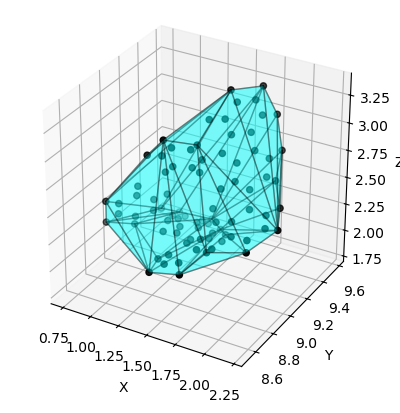

In [ ]:
alpha_ani(
    points = results[10]['unwrapped'], 
    faces = results[10]['faces'], 
    save = "test.mp4", 
    writer="ffmpeg"
    )

## Ray-triangle intersection

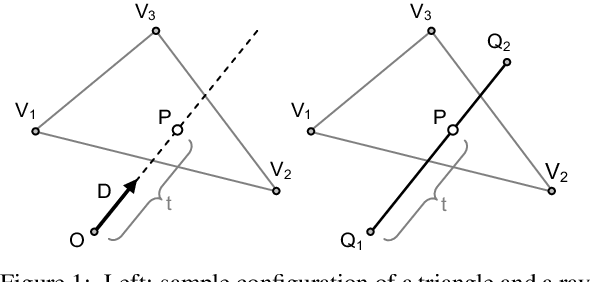

In [6]:
def ray_triangle_intersect(p0, d, v0, v1, v2):
    """
    Möller–Trumbore ray-triangle intersection.
    
    p0 : (3,) array - ray origin
    d  : (3,) array - ray direction (not necessarily normalized)
    v0,v1,v2 : (3,) arrays - triangle vertices
    
    Returns
    -------
    (t,u,v) if intersect, else None
    where intersection point = p0 + t*d
    """
    eps = 1e-9
    e1 = v1 - v0
    e2 = v2 - v0
    h = np.cross(d, e2)
    a = np.dot(e1, h)

    if -eps < a < eps:
        return None  # parallel
    f = 1.0 / a
    s = p0 - v0
    u = f * np.dot(s, h)

    if u < 0.0 or u > 1.0:
        return None

    q = np.cross(s, e1)
    v = f * np.dot(d, q)

    if v < 0.0 or u + v > 1.0:
        return None
        
    t = f * np.dot(e2, q)

    if t > eps:
        return t, u, v

    return None


def line_intersects_mesh(p0, p1, vertices, faces):
    """Return all intersection points of a line segment with a mesh."""
    d = p1 - p0
    intersections = []
    for face in faces:
        v0, v1, v2 = vertices[list(face)]
        result = ray_triangle_intersect(p0, d, v0, v1, v2)
        if result is not None:
            t, u, v = result
            if 0 <= t <= 1:  # within line segment
                intersections.append(p0 + t*d)
    return intersections


### Ray-alpha shape intersection

In [7]:
def line_intersects_alpha_shape(p0, p1, points, faces):
    """
    Test if a line segment (p0,p1) passes through an alpha-shape mesh.
    
    Parameters
    ----------
    p0, p1 : (3,) arrays
        Endpoints of the line segment
    points : (n,3) array
        Alpha-shape vertices
    faces : list of (3,) tuples
        Triangles forming the concave hull surface
    
    Returns
    -------
    intersections : list of (3,) arrays
        Intersection points along the line segment
    """
    d = p1 - p0

    intersections = []
    for face in faces:
        v0, v1, v2 = points[list(face)]
        result = ray_triangle_intersect(p0, d, v0, v1, v2)
        if result is not None:
            t, u, v = result
            if 0 <= t <= 1:
                intersections.append(p0 + t * d)

    return intersections

def passes_through_alpha_shape(p0, p1, points, faces):
    """
    Returns True if the line passes through the alpha-shape volume.
    """

    intersections = line_intersects_alpha_shape(p0, p1, points, faces)
    
    return len(intersections)


In [46]:
points = results[10]['unwrapped']
faces = results[10]['faces']

# Define line
p0 = np.array([1.4, 9.6, 1.75])  # start outside
p1 = np.array([1.5, 8.8, 3.2])  # end outside

# Check
num_of_intersection = passes_through_alpha_shape(p0, p1, points, faces)

print(f"Line passes through the molecule {num_of_intersection} times.")


Line passes through the molecule 2 times.


In [ ]:
# Define line
p0 = np.array([1.4, 9.6, 1.75])  # start outside
p1 = np.array([1.5, 9, 2.5])  # end inside

# Check
num_of_intersection = passes_through_alpha_shape(p0, p1, points, faces)

print(f"Line passes through the molecule {num_of_intersection} times.")


Line passes through the molecule 1 times.


In [ ]:
# Define line
p0 = np.array([1.4, 9.6, 1.75])  # start outside
p1 = np.array([1.5, 9, 1.75])  # end outside

# Check
num_of_intersection = passes_through_alpha_shape(p0, p1, points, faces)

print(f"Line passes through the molecule {num_of_intersection} times.")


Line passes through the molecule 0 times.


#### Animation

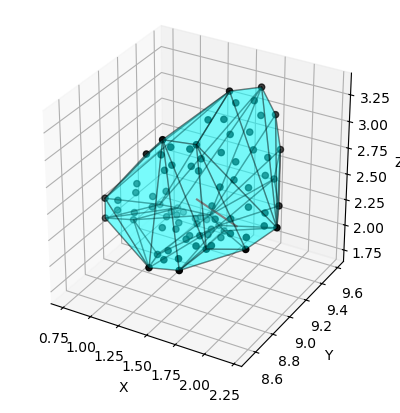

In [ ]:
# Create figure
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

# Plot points
ax.scatter(points[:,0], points[:,1], points[:,2], color="k", s=20)

# Plot hull
faces_list = [points[list(face)] for face in faces]
poly3d = Poly3DCollection(faces_list, alpha=0.3, facecolor="cyan", edgecolor="k")
ax.add_collection3d(poly3d)

# Set equal aspect ratio for the 3D axes
ax.set_box_aspect([1,1,1])  

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

# Plot line segment
ax.plot([p0[0], p1[0]], [p0[1], p1[1]], [p0[2], p1[2]], color="red")

# Animation: rotate the camera
def rotate(angle):
    ax.view_init(elev=30, azim=angle)

anim = FuncAnimation(fig, rotate, frames=np.arange(0, 360, 2), interval=100)

plt.show()

anim.save("./animation/alpha_line_1_times.mp4", 'ffmpeg', fps=30)


## Trimesh

- Trimesh automatically builds a BVH-like structure for meshes.
- A bounding volume hierarchy (BVH) is a tree structure used to organize geometric objects in computer graphics.
- Lets you do ray–mesh intersection queries efficiently.

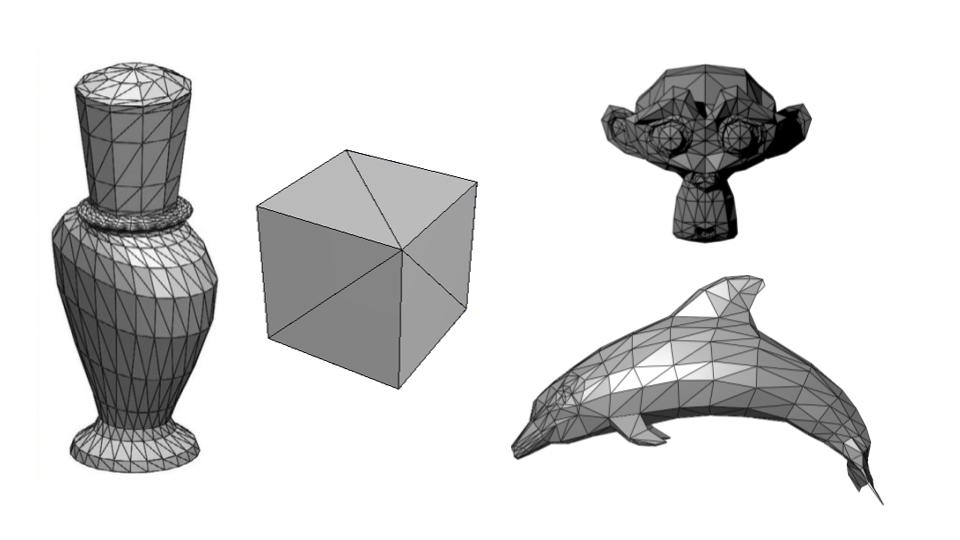

In [18]:
import trimesh

def build_alpha_shape_mesh(points, faces):
    """
    Convert alpha shape (points + faces) into a trimesh object.
    
    Parameters
    ----------
    points : (n,3) array
        Alpha-shape vertices
    faces : list of (3,) tuples
        Triangles forming the concave hull
    
    Returns
    -------
    mesh : trimesh.Trimesh
        Watertight mesh for acceleration structure & intersection queries
    """
    mesh = trimesh.Trimesh(vertices=points, faces=faces, process=True)
    return mesh


def line_intersects_alpha_shape_trimesh(p0, p1, mesh):
    """
    Test if a line segment (p0,p1) passes through an alpha-shape mesh
    using trimesh ray-tracing (with acceleration).
    
    Parameters
    ----------
    p0, p1 : (3,) arrays
        Endpoints of the line segment
    mesh : trimesh.Trimesh
        Concave hull mesh
    
    Returns
    -------
    intersections : list of (3,) arrays
        Intersection points with the mesh
    """
    ray_dir = p1 - p0
    ray_len = np.linalg.norm(ray_dir)
    if ray_len == 0:
        return []
    ray_dir = ray_dir / ray_len  # normalize
    
    # Query intersections
    locations, index_ray, index_tri = mesh.ray.intersects_location(
        ray_origins=[p0],
        ray_directions=[ray_dir]
    )
    
    # Filter intersections inside the line segment
    intersections = []
    for loc in locations:
        t = np.dot(loc - p0, ray_dir) / ray_len
        if 0 <= t <= 1:
            intersections.append(loc)
    
    return intersections


def passes_through_alpha_shape_trimesh(p0, p1, mesh):
    """
    Returns True if line passes through the alpha-shape volume.
    """
    intersections = line_intersects_alpha_shape_trimesh(p0, p1, mesh)
    return len(intersections) >= 2


In [47]:
# Build trimesh from alpha-shape
mesh = build_alpha_shape_mesh(points, faces)


# Check intersections
intersections = line_intersects_alpha_shape_trimesh(np.array([1.4, 9.6, 1.75]), np.array([1.5, 9, 2.5]), mesh)
print("Intersection points:", intersections)

if passes_through_alpha_shape_trimesh(np.array([1.4, 9.6, 1.75]), np.array([1.5, 9, 2.5]), mesh):
    print("Line passes through the molecule hull (blocked).")
else:
    print("Line does not pass through the hull.")

Intersection points: [array([1.42878102, 9.4273139 , 1.96585762])]
Line does not pass through the hull.


In [52]:
mesh.show()

In [48]:
# Check intersections
intersections = line_intersects_alpha_shape_trimesh(np.array([1.4, 9.6, 1.75]), np.array([1.5, 8.8, 3.2]), mesh)
print("Intersection points:", intersections)

if passes_through_alpha_shape_trimesh(np.array([1.4, 9.6, 1.75]), np.array([1.5, 8.8, 3.2]), mesh):
    print("Line passes through the molecule hull (blocked).")
else:
    print("Line does not pass through the hull.")

Intersection points: [array([1.49026955, 8.87784357, 3.05890853]), array([1.41721082, 9.46231347, 1.99955683])]
Line passes through the molecule hull (blocked).


## Neighbouring test

In [19]:
import numpy as np
from math import isclose
from tqdm import tqdm  # for loops progress


# Minimum-image vector
def mic_vector(dx, box_length):
    """
    Return minimum-image displacement for vector(s) dx.
    dx can be shape (..., 3) or (3,)
    """
    return dx - np.rint(dx / box_length) * box_length


# Precompute wrapped vertices and bounding spheres
def prepare_hulls_and_spheres(results, mid_df, box_length):
    """
    From results dict produce:
      - wrapped_vertices[i] = vertices in primary cell [0, L)
      - faces[i] = faces list/array
      - sphere_radius[i] = bounding sphere radius (MIC) around midpoints
      - sphere_center[i] = midpoint from mid_df as np.array
    Returns dicts keyed by molecule id.
    """
    wrapped_vertices = {}
    faces_dict = {}
    sphere_center = {}
    sphere_radius = {}
    
    for i, info in results.items():
        unwrapped = np.asarray(info["unwrapped"])  # (nverts, 3)
        faces = info["faces"]

        # wrap into primary cell
        wrapped = np.mod(unwrapped, box_length)
        wrapped_vertices[i] = wrapped
        faces_dict[i] = np.asarray(faces, dtype=int)

        # center: from mid_df (assumed in box coords)
        c = mid_df.loc[i, ["midO_x", "midO_y", "midO_z"]].values.astype(float)
        sphere_center[i] = c
        
        # compute MIC-based distances from center to vertices (vectorized)
        diffs = mic_vector(wrapped - c, box_length)  # shape (nverts,3)
        dists = np.linalg.norm(diffs, axis=1)
        sphere_radius[i] = float(np.max(dists)) if len(dists) > 0 else 0.0

    return wrapped_vertices, faces_dict, sphere_center, sphere_radius

In [20]:
wrapped_vertices, faces_dict, sphere_center, sphere_radius = prepare_hulls_and_spheres(
        results, df_midO, box_length
    )

In [ ]:
# Distance point-to-segment (Euclidean)
def point_segment_distance(p, a, b):
    """
    Euclidean distance from point p to segment [a,b].
    p,a,b are 3-vectors (numpy arrays).
    """
    ab = b - a
    ab_len_sq = np.dot(ab, ab)
    if isclose(ab_len_sq, 0.0):
        return np.linalg.norm(p - a)
    t = np.dot(p - a, ab) / ab_len_sq
    t_clamped = np.clip(t, 0.0, 1.0)
    closest = a + t_clamped * ab
    
    return np.linalg.norm(p - closest)


In [28]:
# Function to test a single pair
def pair_is_neighbor(i, j, wrapped_vertices, faces_dict,
                     sphere_center, sphere_radius,
                     box_length, max_blockers_check=500):
    """
    Test whether molecule i and j are neighbors (unblocked).
    Use midpoint centers in sphere_center as reference points.
    Optional max_blockers_check: limit number of blocker meshes to test exactly
      (helps performance); choose blockers by descending expected overlap.
    Returns True if neighbors (no blockers), False if blocked.
    """
    # endpoints in wrapped (primary) coordinates
    ca = sphere_center[i]
    cb_wrapped = sphere_center[j]
    # Build MIC segment from ca to cb in A's frame
    cb_in_A = ca + mic_vector(cb_wrapped - ca, box_length)
    p0 = ca
    p1 = cb_in_A
    seg_len = np.linalg.norm(p1 - p0)
    if isclose(seg_len, 0.0):
        # same midpoint -> neighbors trivially
        return True

    # ray direction normalized for trimesh
    ray_dir = (p1 - p0) / seg_len

    # Gather candidate blockers by quick sphere overlap along segment:
    # For each k != i, j compute distance from center_k to segment (in A-frame using MIC),
    # if dist <= radius_k -> possible blocker
    candidate_blockers = []
    for k, center_k in sphere_center.items():
        if k == i or k == j:
            continue
        # place center_k into A frame: choose image nearest to ca
        ck_in_A = ca + mic_vector(center_k - ca, box_length)
        # distance from center to segment
        dmin = point_segment_distance(ck_in_A, p0, p1)
        if dmin <= sphere_radius[k]:
            candidate_blockers.append((k, dmin))

    # Sort candidates by proximity so we test the most likely blockers first
    candidate_blockers.sort(key=lambda x: x[1])

    # Optionally cap number of exact tests (tune max_blockers_check)
    if max_blockers_check is not None and len(candidate_blockers) > max_blockers_check:
        candidate_blockers = candidate_blockers[:max_blockers_check]

    # Exact check: for each candidate, transform its wrapped vertices into A-frame,
    # build trimesh, and query ray intersections (BVH accelerated)
    for k, _ in candidate_blockers:
        verts_wrapped = wrapped_vertices[k]  # shape (nverts,3)
        faces_k = faces_dict[k]
        # Transform each vertex to image closest to p0 (A's frame)
        verts_in_A = p0 + mic_vector(verts_wrapped - p0, box_length)
        # Build trimesh mesh for this hull
        try:
            mesh_k = trimesh.Trimesh(vertices=verts_in_A, faces=faces_k, process=False)
        except Exception:
            # if trimesh cannot build (degenerate faces), fallback to direct triangle check
            mesh_k = None

        if mesh_k is not None:
            # ray tracing (trimesh returns all intersections on infinite ray)
            try:
                locations, index_ray, index_tri = mesh_k.ray.intersects_location(
                    ray_origins=[p0],
                    ray_directions=[ray_dir]
                )
            except Exception:
                locations = np.array([])

            # Filter locations to the finite segment length
            for loc in locations:
                t_along = np.dot(loc - p0, ray_dir)  # distance along ray (since dir unit)
                if 0.0 <= t_along <= seg_len:
                    # intersects within the segment -> blocked
                    return False
        else:
            # fallback: brute-force triangle intersections using Moller-Trumbore
            vtris = verts_in_A[faces_k]  # (nfaces,3,3)
            p0_local = p0
            d_local = p1 - p0
            for tri in vtris:
                v0, v1, v2 = tri
                res = ray_triangle_intersect(p0_local, d_local, v0, v1, v2)
                if res is not None:
                    t, u, v = res
                    if 0 <= t <= 1:
                        return False

    # no blockers found
    return True

In [29]:
# Build neighbor list
def build_neighbor_list(results, mid_df, box_length,
                        max_blockers_check=500, progress=True):
    """
    Loop over all pairs (i<j) and return a list of neighbor pairs (tuples).
    Uses candidate bounding-sphere quick-reject and trimesh-accelerated exact tests.
    """
    # Prepare hull/wrapped and sphere data
    wrapped_vertices, faces_dict, sphere_center, sphere_radius = prepare_hulls_and_spheres(
        results, mid_df, box_length
    )

    res_ids = sorted(results.keys())
    neighbors = []  # list of tuples (i, j)

    iterator = ((a, b) for idx, a in enumerate(res_ids) for b in res_ids[idx+1:])
    if progress:
        total_pairs = len(res_ids)*(len(res_ids)-1)//2
        iterator = tqdm(iterator, total=total_pairs, desc="pairs")

    for i, j in iterator:
        is_neigh = pair_is_neighbor(i, j, wrapped_vertices, faces_dict,
                                    sphere_center, sphere_radius,
                                    box_length, max_blockers_check=max_blockers_check)
        if is_neigh:
            neighbors.append((i, j))

    return neighbors

In [36]:
build_neighbor_list(results, df_midO, box_length, max_blockers_check=50, progress=True)

pairs:   1%|          | 8374/1125750 [02:13<4:56:09, 62.88it/s] 


KeyboardInterrupt: 

### Pre-filters candidate pairs with a periodic KD-tree, so it doesn’t loop over all $^{n}C_{2}$ pairs.

In [40]:
from scipy.spatial import cKDTree  # periodic KD-tree via boxsize

# Fast prefilter with periodic KD-tree
def candidate_pairs_periodic(midpoints, box_length, pair_cutoff):
    """
    Use cKDTree with periodic distances (boxsize) to get pairs within pair_cutoff.
    Returns an ndarray of shape (M,2) with index pairs (i<j).
    """
    tree = cKDTree(midpoints, boxsize=box_length)
    # query_pairs returns indices with i<j
    pairs = tree.query_pairs(r=pair_cutoff, output_type='ndarray')
    return pairs


# Top-level builder with prefilter
def build_neighbor_list_prefiltered(results, mid_df, box_length,
                                    max_blockers_check=300,
                                    progress=True):
    """
    1) Prepare hulls and bounding spheres.
    2) Periodic KD-tree to get only nearby pairs (within pair_cutoff).
    3) For each candidate pair, run the blocking test.
    Returns: list of (res_id_i, res_id_j)
    """
    # Prepare geometry & bounding data
    wrapped_vertices, faces_dict, sphere_center, sphere_radius = prepare_hulls_and_spheres(
        results, mid_df, box_length
    )

    # Build an array of centers ordered by res_id (sorted for determinism)
    res_ids = np.array(sorted(results.keys()))
    centers = np.vstack([sphere_center[i] for i in res_ids])

    # quick heuristic to pick a cutoff = 95th percentile of nearest-neighbor distances
    tree = cKDTree(centers, boxsize=box_length)
    d1, _ = tree.query(centers, k=2)   # k=1 is itself (0), k=2 is nearest neighbor
    nn_dist = d1[:,1]
    pair_cutoff = float(np.quantile(nn_dist, 0.95))

    # Prefilter pairs within cutoff using periodic KD-tree
    cand_pairs_idx = candidate_pairs_periodic(centers, box_length, pair_cutoff)
    # Map back to res_ids
    cand_pairs = [(int(res_ids[i]), int(res_ids[j])) for i, j in cand_pairs_idx]

    neighbors = []
    iterator = cand_pairs
    if progress:
        iterator = tqdm(iterator, total=len(cand_pairs), desc=f"pairs<= {pair_cutoff:g}")

    for i, j in iterator:
        if pair_is_neighbor(i, j,
                            wrapped_vertices, faces_dict,
                            sphere_center, sphere_radius,
                            box_length,
                            max_blockers_check=max_blockers_check):
            neighbors.append((i, j))

    return neighbors

In [42]:
neighbors_list = build_neighbor_list_prefiltered(results, df_midO, box_length, max_blockers_check=300, progress=True)

pairs<= 0.876505: 100%|██████████| 1659/1659 [00:27<00:00, 60.72it/s]


In [43]:
len(neighbors_list)

1570